# Neural Network for Pima Indians Diabetes Prediction

## 🎯 Project Overview
Build a binary classification neural network to predict diabetes in Pima Indian women based on clinical measurements.

**Dataset**: UCI Machine Learning Repository (via Kaggle)  
**Target**: Binary classification (No Diabetes / Diabetes)  


## 📚 Part 1: Import Libraries and Load Dataset

In [134]:
# Install and import kagglehub
# !pip install kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter

# Import all necessary libraries for the assignment
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from tensorflow.keras import models, layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns

print("Loading Pima Indians Diabetes dataset from Kaggle...")
print("=" * 70)

# Load the dataset using kagglehub with specific file name
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "uciml/pima-indians-diabetes-database",
    "diabetes.csv",  # Specify the CSV file name
)

print("✓ Dataset loaded successfully!")
print(f"\nDataset shape: {df.shape}")
print(f"\nFirst 5 records:")
print(df.head())
print(f"\nColumn names:")
print(df.columns.tolist())
print(f"\nData types:")
print(df.dtypes)

Loading Pima Indians Diabetes dataset from Kaggle...
✓ Dataset loaded successfully!

Dataset shape: (768, 9)

First 5 records:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data types:
Pregnancies            

### 📊 Dataset Features

| Feature | Description | Unit |
|---------|-------------|------|
| Pregnancies | Number of pregnancies | count |
| Glucose | Plasma glucose concentration | mg/dL |
| BloodPressure | Diastolic blood pressure | mmHg |
| SkinThickness | Triceps skinfold thickness | mm |
| Insulin | 2-hour serum insulin | μU/mL |
| BMI | Body mass index | kg/m² |
| DiabetesPedigreeFunction | Diabetes heredity score | score |
| Age | Age | years |

**Target**: `Outcome` (0 = No Diabetes, 1 = Diabetes)

## 🔍 Part 2: Exploratory Data Analysis

In [135]:
# Explore the Pima Indians Diabetes dataset
print("=" * 70)
print("PIMA INDIANS DIABETES DATASET EXPLORATION")
print("=" * 70)

print(f"\nDataset Information:")
print(f"  Total samples: {df.shape[0]}")
print(f"  Total features: {df.shape[1] - 1}")  # Excluding target column

print(f"\nFeatures (Clinical Measurements):")
feature_cols = df.columns[:-1]  # All columns except 'Outcome'
for i, col in enumerate(feature_cols, 1):
    print(f"  {i}. {col}")

print(f"\nTarget Variable: 'Outcome'")
print(f"  0 = No Diabetes")
print(f"  1 = Diabetes")

print(f"\nClass Distribution:")
outcome_counts = df['Outcome'].value_counts()
print(f"  No Diabetes (0): {outcome_counts[0]} samples ({100*outcome_counts[0]/len(df):.1f}%)")
print(f"  Diabetes (1): {outcome_counts[1]} samples ({100*outcome_counts[1]/len(df):.1f}%)")

print(f"\nMissing Values:")
print(df.isnull().sum())

print(f"\nBasic Statistics:")
print(df.describe())



PIMA INDIANS DIABETES DATASET EXPLORATION

Dataset Information:
  Total samples: 768
  Total features: 8

Features (Clinical Measurements):
  1. Pregnancies
  2. Glucose
  3. BloodPressure
  4. SkinThickness
  5. Insulin
  6. BMI
  7. DiabetesPedigreeFunction
  8. Age

Target Variable: 'Outcome'
  0 = No Diabetes
  1 = Diabetes

Class Distribution:
  No Diabetes (0): 500 samples (65.1%)
  Diabetes (1): 268 samples (34.9%)

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Basic Statistics:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972

ZERO VALUES ANALYSIS

Features with zero values (medically impossible/missing data):
----------------------------------------------------------------------
  Pregnancies                111 zeros ( 14.5%)
  Glucose                      5 zeros (  0.7%)
  BloodPressure               35 zeros (  4.6%)
  SkinThickness              227 zeros ( 29.6%)
  Insulin                    374 zeros ( 48.7%)
  BMI                         11 zeros (  1.4%)

✓ Found 6 features with zero values
  These will be replaced with median values during preprocessing


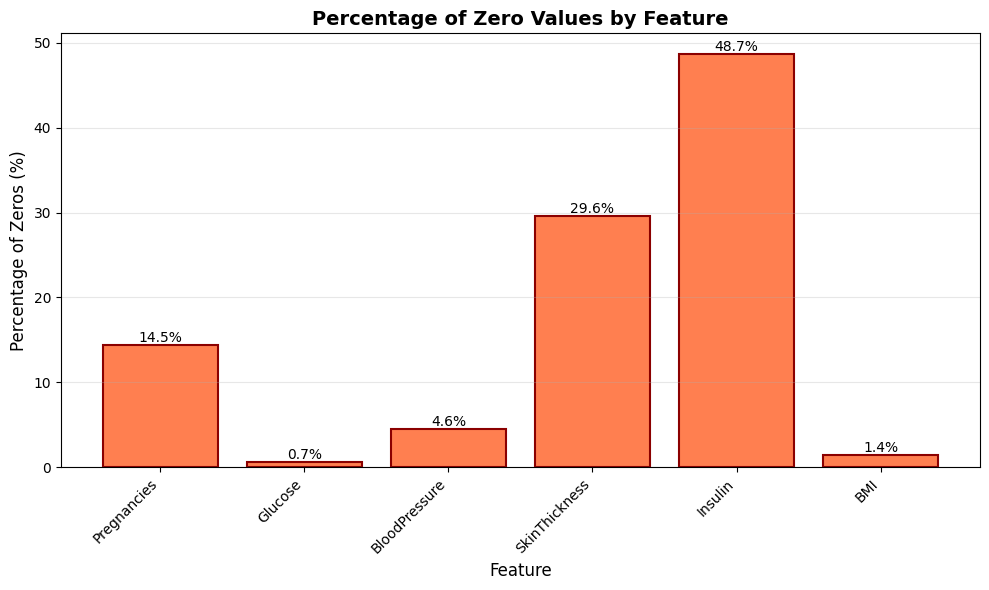

In [136]:
# Analyze zero values in each feature
print("=" * 70)
print("ZERO VALUES ANALYSIS")
print("=" * 70)

print("\nFeatures with zero values (medically impossible/missing data):")
print("-" * 70)

zero_features = []
for col in df.columns[:-1]:  # Exclude 'Outcome' column
    zero_count = (df[col] == 0).sum()
    zero_percentage = (zero_count / len(df)) * 100
    
    if zero_count > 0:
        zero_features.append((col, zero_count, zero_percentage))
        print(f"  {col:<25} {zero_count:>4} zeros ({zero_percentage:>5.1f}%)")

print(f"\n✓ Found {len(zero_features)} features with zero values")
print(f"  These will be replaced with median values during preprocessing")

# Visualize zero value distribution
if zero_features:
    plt.figure(figsize=(10, 6))
    feature_names = [f[0] for f in zero_features]
    percentages = [f[2] for f in zero_features]
    
    bars = plt.bar(feature_names, percentages, color='coral', edgecolor='darkred', linewidth=1.5)
    plt.title('Percentage of Zero Values by Feature', fontsize=14, fontweight='bold')
    plt.xlabel('Feature', fontsize=12)
    plt.ylabel('Percentage of Zeros (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    
    # Add percentage labels on bars
    for bar, pct in zip(bars, percentages):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()

### Key Findings
⚠️ **Missing values disguised as zeros** in medical measurements (Glucose, BloodPressure, SkinThickness, Insulin, BMI)  
**Solution**: Replace zeros with median values from non-zero measurements

## 🛠️ Part 3: Data Preprocessing
Handle missing values, split data, and normalize features for neural network training.

In [137]:
# Prepare data for neural network
print("Preparing Pima Indians Diabetes data...")
print("=" * 70)

# Separate features (X) and target (y)
X_pima = df.drop('Outcome', axis=1).values
y_pima = df['Outcome'].values

print(f"\nOriginal dataset:")
print(f"  Features shape: {X_pima.shape}")
print(f"  Labels shape: {y_pima.shape}")

# Check for zeros in medical measurements (likely missing data)
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
zero_indices = [1, 2, 3, 4, 5]  # Column indices

print(f"\nZero values in medical measurements (likely missing):")
for col_name, col_idx in zip(zero_cols, zero_indices):
    zero_count = np.sum(X_pima[:, col_idx] == 0)
    print(f"  {col_name}: {zero_count} zeros ({100*zero_count/len(X_pima):.1f}%)")

# Replace zeros with median values (simple imputation)
print(f"\nReplacing zeros with median values...")
for col_idx in zero_indices:
    # Calculate median excluding zeros
    non_zero_values = X_pima[X_pima[:, col_idx] != 0, col_idx]
    if len(non_zero_values) > 0:
        median_value = np.median(non_zero_values)
        X_pima[X_pima[:, col_idx] == 0, col_idx] = median_value

print(f"✓ Missing data handled (zeros replaced with medians)")

print(f"\nFeature Value Ranges:")
print(f"  Min values: {X_pima.min(axis=0)}")
print(f"  Max values: {X_pima.max(axis=0)}")
print(f"  Note: Features have different scales → normalization required!")

Preparing Pima Indians Diabetes data...

Original dataset:
  Features shape: (768, 8)
  Labels shape: (768,)

Zero values in medical measurements (likely missing):
  Glucose: 5 zeros (0.7%)
  BloodPressure: 35 zeros (4.6%)
  SkinThickness: 227 zeros (29.6%)
  Insulin: 374 zeros (48.7%)
  BMI: 11 zeros (1.4%)

Replacing zeros with median values...
✓ Missing data handled (zeros replaced with medians)

Feature Value Ranges:
  Min values: [ 0.    44.    24.     7.    14.    18.2    0.078 21.   ]
  Max values: [ 17.   199.   122.    99.   846.    67.1    2.42  81.  ]
  Note: Features have different scales → normalization required!


### Train-Test Split
Split with stratification to maintain class distribution in both sets.

In [138]:
# Step 1: Split data into training and testing sets (80-20 split)
X_train_pima, X_test_pima, y_train_pima, y_test_pima = train_test_split(
    X_pima, y_pima,
    test_size=0.2,           # 20% for testing
    random_state=42,         # For reproducibility
    stratify=y_pima          # Keep class distribution in both sets
)

print(f"Data Split:")
print(f"  Training set size: {X_train_pima.shape[0]} samples")
print(f"  Testing set size: {X_test_pima.shape[0]} samples")

print(f"\nTraining set class distribution:")
print(f"  No Diabetes (0): {np.sum(y_train_pima == 0)} ({100*np.sum(y_train_pima==0)/len(y_train_pima):.1f}%)")
print(f"  Diabetes (1): {np.sum(y_train_pima == 1)} ({100*np.sum(y_train_pima==1)/len(y_train_pima):.1f}%)")

print(f"\nBefore Scaling - Feature Statistics:")
print(f"  Mean: {X_train_pima.mean(axis=0)[:3]}")
print(f"  Std Dev: {X_train_pima.std(axis=0)[:3]}")

Data Split:
  Training set size: 614 samples
  Testing set size: 154 samples

Training set class distribution:
  No Diabetes (0): 400 (65.1%)
  Diabetes (1): 214 (34.9%)

Before Scaling - Feature Statistics:
  Mean: [  3.81921824 121.67100977  72.14006515]
  Std Dev: [ 3.31144822 29.97935076 12.26511926]


### Feature Scaling
Normalize features to mean=0, std=1. Neural networks converge faster with normalized inputs and prevents features with larger scales from dominating learning.

In [139]:
# Step 2: Scale features using StandardScaler
scaler_pima = StandardScaler()

# Fit on training data and transform it
X_train_pima_scaled = scaler_pima.fit_transform(X_train_pima)

# Transform test data using training statistics (DO NOT refit!)
X_test_pima_scaled = scaler_pima.transform(X_test_pima)

print("After Scaling - Feature Statistics:")
print(f"  Training mean: {X_train_pima_scaled.mean(axis=0)[:3]} (should be ~0)")
print(f"  Training std dev: {X_train_pima_scaled.std(axis=0)[:3]} (should be ~1)")
print(f"  Test mean: {X_test_pima_scaled.mean(axis=0)[:3]} (close to 0)")
print(f"  Test std dev: {X_test_pima_scaled.std(axis=0)[:3]} (close to 1)")

print(f"\n✓ Data preprocessing complete for Pima Indians Diabetes dataset!")

After Scaling - Feature Statistics:
  Training mean: [-1.87146715e-17 -8.02832285e-17  3.23302731e-16] (should be ~0)
  Training std dev: [1. 1. 1.] (should be ~1)
  Test mean: [ 0.03890555 -0.00245526  0.10028967] (close to 0)
  Test std dev: [1.08105932 1.07105375 0.92172508] (close to 1)

✓ Data preprocessing complete for Pima Indians Diabetes dataset!


## 🧠 Part 4: Build Neural Network

**Architecture**: Input(8) → Dense(32, ReLU) → Dense(16, ReLU) → Output(1, Sigmoid)

Progressive dimensionality reduction with ReLU activation for non-linearity and sigmoid output for binary probability.

In [140]:
# Build the neural network model for Pima Indians Diabetes
model_pima = models.Sequential([
    layers.Dense(32, activation='relu', input_shape=(8,)),    # Input: 8 features
    layers.Dense(16, activation='relu'),                       # Hidden layer 2
    layers.Dense(1, activation='sigmoid')                      # Output: probability
])

# Display model architecture
print("Model Architecture for Pima Indians Diabetes:")
print("=" * 70)
model_pima.summary()

Model Architecture for Pima Indians Diabetes:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

## ⚙️ Part 5: Compile and Train Model

**Configuration**: Adam optimizer (lr=0.001), Binary Crossentropy loss, Early Stopping (patience=10)

In [141]:
# Compile the model
model_pima.compile(
    optimizer=Adam(learning_rate=0.001),        # Adaptive optimizer
    loss='binary_crossentropy',                 # For binary classification
    metrics=['binary_accuracy']                 # Track accuracy during training
)

print("✓ Model compiled successfully!")
print("\nConfiguration:")
print("  Optimizer: Adam (learning_rate=0.001)")
print("  Loss: Binary Crossentropy")
print("  Metric: Binary Accuracy")

✓ Model compiled successfully!

Configuration:
  Optimizer: Adam (learning_rate=0.001)
  Loss: Binary Crossentropy
  Metric: Binary Accuracy


### Training
Max 150 epochs with early stopping monitoring validation loss. Batch size: 32, Validation split: 20%

In [142]:
# Set up Early Stopping to prevent overfitting
early_stop_pima = EarlyStopping(
    monitor='val_loss',                      # Watch validation loss
    patience=10,                             # Stop if no improvement for 10 epochs
    restore_best_weights=True,               # Return to best weights
    verbose=1
)

# Train the model with Early Stopping
print("Starting training on Pima Indians Diabetes dataset...")
print("=" * 70)
history_pima = model_pima.fit(
    X_train_pima_scaled, y_train_pima,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop_pima],
    verbose=1
)

print("\n✓ Training complete!")

Starting training on Pima Indians Diabetes dataset...
Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - binary_accuracy: 0.5393 - loss: 0.6933 - val_binary_accuracy: 0.6179 - val_loss: 0.6416
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.7753 - loss: 0.6255 - val_binary_accuracy: 0.6911 - val_loss: 0.5988
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.7629 - loss: 0.5861 - val_binary_accuracy: 0.7154 - val_loss: 0.5605
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.7646 - loss: 0.5437 - val_binary_accuracy: 0.7317 - val_loss: 0.5274
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.7558 - loss: 0.5311 - val_binary_accuracy: 0.7317 - val_loss: 0.5061
Epoch 6/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.7752 - loss: 0.4992 - val_binary_accuracy: 0.7398 - val_loss: 0.4853
Epoch 7/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.7539 - loss: 0.5055 - val_b

## 📉 Part 6: Visualize Training History

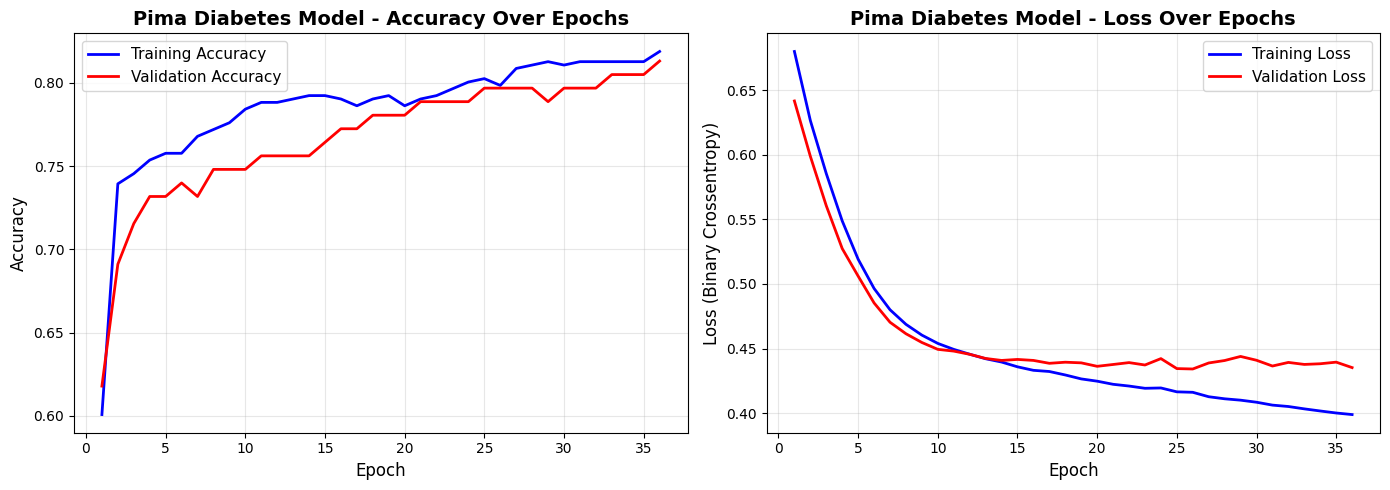

✓ Training visualization complete!

Final Training Accuracy: 0.8187
Final Validation Accuracy: 0.8130
Accuracy Gap: 0.0057


In [143]:
# Extract history data for Pima Indians Diabetes model
loss_values_pima = history_pima.history['loss']
val_loss_values_pima = history_pima.history['val_loss']
accuracy_values_pima = history_pima.history['binary_accuracy']
val_accuracy_values_pima = history_pima.history['val_binary_accuracy']

epochs_pima = range(1, len(loss_values_pima) + 1)

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy
ax1.plot(epochs_pima, accuracy_values_pima, 'b-', label='Training Accuracy', linewidth=2)
ax1.plot(epochs_pima, val_accuracy_values_pima, 'r-', label='Validation Accuracy', linewidth=2)
ax1.set_title('Pima Diabetes Model - Accuracy Over Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: Loss
ax2.plot(epochs_pima, loss_values_pima, 'b-', label='Training Loss', linewidth=2)
ax2.plot(epochs_pima, val_loss_values_pima, 'r-', label='Validation Loss', linewidth=2)
ax2.set_title('Pima Diabetes Model - Loss Over Epochs', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss (Binary Crossentropy)', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Training visualization complete!")
print(f"\nFinal Training Accuracy: {accuracy_values_pima[-1]:.4f}")
print(f"Final Validation Accuracy: {val_accuracy_values_pima[-1]:.4f}")
print(f"Accuracy Gap: {abs(accuracy_values_pima[-1] - val_accuracy_values_pima[-1]):.4f}")

### Training Curve Analysis
**Accuracy plot**: Both curves should increase; small gap indicates good generalization  
**Loss plot**: Both should decrease and converge; large gap suggests overfitting

## 🎯 Part 7: Evaluate Model Performance

In [144]:
# Evaluate the model on test data
test_loss_pima, test_accuracy_pima = model_pima.evaluate(X_test_pima_scaled, y_test_pima, verbose=0)

print("=" * 70)
print("MODEL EVALUATION ON TEST DATA")
print("=" * 70)
print(f"\nTest Loss: {test_loss_pima:.4f}")
print(f"Test Accuracy: {test_accuracy_pima:.4f} ({test_accuracy_pima*100:.2f}%)")

print(f"\n✓ Model successfully evaluated on unseen test data!")

MODEL EVALUATION ON TEST DATA

Test Loss: 0.5264
Test Accuracy: 0.7338 (73.38%)

✓ Model successfully evaluated on unseen test data!


## 📊 Part 8: Confusion Matrix & Detailed Metrics

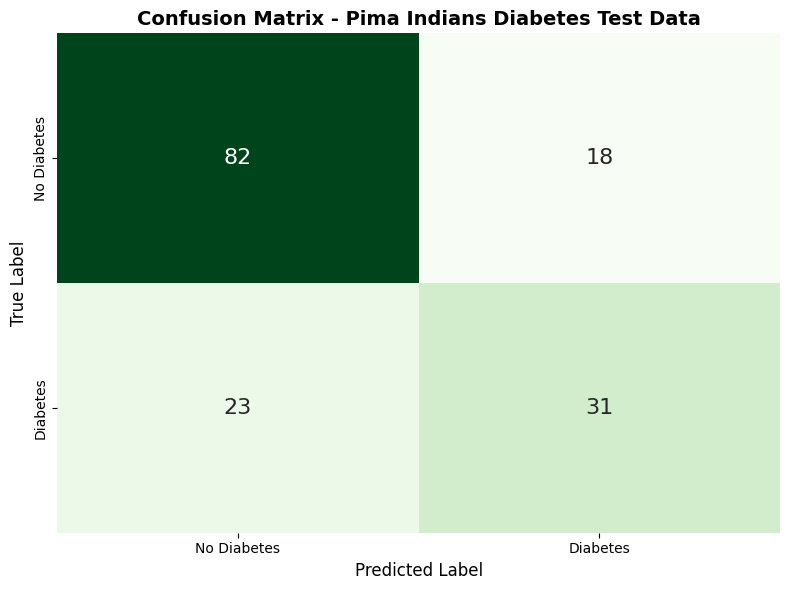


Confusion Matrix Breakdown:
  True Negatives (TN):  82  (Correctly identified no diabetes)
  False Positives (FP): 18  (Incorrectly predicted diabetes)
  False Negatives (FN): 23  (Missed diabetes cases) ⚠️
  True Positives (TP):  31  (Correctly identified diabetes)


In [145]:
# Make predictions on test data
y_pred_prob_pima = model_pima.predict(X_test_pima_scaled, verbose=0)  # Get probabilities
y_pred_pima = (y_pred_prob_pima > 0.5).astype(int).flatten()  # Convert to class labels

# Calculate confusion matrix
cm_pima = confusion_matrix(y_test_pima, y_pred_pima)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_pima, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'],
            annot_kws={'size': 16})
plt.title('Confusion Matrix - Pima Indians Diabetes Test Data', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print("\nConfusion Matrix Breakdown:")
print(f"  True Negatives (TN):  {cm_pima[0, 0]}  (Correctly identified no diabetes)")
print(f"  False Positives (FP): {cm_pima[0, 1]}  (Incorrectly predicted diabetes)")
print(f"  False Negatives (FN): {cm_pima[1, 0]}  (Missed diabetes cases) ⚠️")
print(f"  True Positives (TP):  {cm_pima[1, 1]}  (Correctly identified diabetes)")

### Medical Significance
🚨 **False Negatives (FN)** are critical - missing diabetes can lead to serious complications  
⚠️ **False Positives (FP)** are less critical - patients can be retested

## 📈 Part 9: Classification Metrics

In [146]:
# Calculate additional metrics
precision_pima = precision_score(y_test_pima, y_pred_pima)
recall_pima = recall_score(y_test_pima, y_pred_pima)
f1_pima = f1_score(y_test_pima, y_pred_pima)

# Calculate metrics for no diabetes class
precision_no_diabetes = precision_score(y_test_pima, y_pred_pima, pos_label=0)
recall_no_diabetes = recall_score(y_test_pima, y_pred_pima, pos_label=0)

print("=" * 70)
print("DETAILED CLASSIFICATION METRICS")
print("=" * 70)

print(f"\nOverall Metrics:")
print(f"  Accuracy:  {test_accuracy_pima:.4f} ({test_accuracy_pima*100:.2f}%)")
print(f"  Precision: {precision_pima:.4f} (of predicted diabetes, {precision_pima*100:.2f}% are correct)")
print(f"  Recall:    {recall_pima:.4f} (we catch {recall_pima*100:.2f}% of actual diabetes cases)")
print(f"  F1-Score:  {f1_pima:.4f} (harmonic mean of precision and recall)")

print(f"\nDiabetes Detection (Class 1):")
print(f"  Precision: {precision_pima:.4f}")
print(f"  Recall:    {recall_pima:.4f}")

print(f"\nNo Diabetes Detection (Class 0):")
print(f"  Precision: {precision_no_diabetes:.4f}")
print(f"  Recall:    {recall_no_diabetes:.4f}")

print(f"\n📊 Medical Interpretation:")
print(f"  • False Negatives: {cm_pima[1, 0]} cases (missed diabetes diagnoses) ⚠️")
print(f"  • False Positives: {cm_pima[0, 1]} cases (false alarms)")
print(f"  • Recall is critical: Missing diabetes diagnosis has serious health consequences")
print(f"  • Current recall: {recall_pima*100:.1f}% of diabetes cases detected")

print(f"\n💡 Model Insights:")
if recall_pima < 0.70:
    print(f"  ⚠️ Low recall - Consider adjusting decision threshold or adding more features")
if precision_pima < 0.70:
    print(f"  ⚠️ Low precision - Model produces many false positives")
if f1_pima >= 0.70:
    print(f"  ✓ Good balance between precision and recall")

DETAILED CLASSIFICATION METRICS

Overall Metrics:
  Accuracy:  0.7338 (73.38%)
  Precision: 0.6327 (of predicted diabetes, 63.27% are correct)
  Recall:    0.5741 (we catch 57.41% of actual diabetes cases)
  F1-Score:  0.6019 (harmonic mean of precision and recall)

Diabetes Detection (Class 1):
  Precision: 0.6327
  Recall:    0.5741

No Diabetes Detection (Class 0):
  Precision: 0.7810
  Recall:    0.8200

📊 Medical Interpretation:
  • False Negatives: 23 cases (missed diabetes diagnoses) ⚠️
  • False Positives: 18 cases (false alarms)
  • Recall is critical: Missing diabetes diagnosis has serious health consequences
  • Current recall: 57.4% of diabetes cases detected

💡 Model Insights:
  ⚠️ Low recall - Consider adjusting decision threshold or adding more features
  ⚠️ Low precision - Model produces many false positives


### Metrics Explained
**Accuracy**: Overall correctness  
**Precision**: Of predicted diabetes, how many are correct?  
**Recall**: Of actual diabetes, how many did we catch?  
**F1-Score**: Balanced measure of precision and recall

For medical applications, high recall is critical (catch all cases) while lower precision is more acceptable.

In [147]:
# Final summary
print("=" * 70)
print("ASSIGNMENT SUMMARY")
print("=" * 70)

print(f"\n📋 Dataset:")
print(f"  Total Samples: {df.shape[0]}")
print(f"  Features: {df.shape[1] - 1}")
print(f"  Train/Test Split: {X_train_pima.shape[0]}/{X_test_pima.shape[0]}")

print(f"\n🏗️ Model Architecture:")
print(f"  Input → Dense(32, ReLU) → Dense(16, ReLU) → Output(1, Sigmoid)")
print(f"  Total Parameters: {model_pima.count_params()}")

print(f"\n📊 Model Performance:")
print(f"  Test Accuracy: {test_accuracy_pima:.4f} ({test_accuracy_pima*100:.2f}%)")
print(f"  Precision: {precision_pima:.4f}")
print(f"  Recall: {recall_pima:.4f}")
print(f"  F1-Score: {f1_pima:.4f}")
print(f"  Training Epochs: {len(loss_values_pima)}")

print(f"\n💡 Key Insights:")
print(f"  • Replaced {sum([len(df[df[col] == 0]) for col in zero_cols])} zero values with medians")
print(f"  • Feature scaling normalized all measurements")
print(f"  • Early stopping prevented overfitting")
print(f"  • False Negatives: {cm_pima[1, 0]} (critical missed cases)")
print(f"  • False Positives: {cm_pima[0, 1]} (less critical)")

print(f"\n" + "=" * 70)
print("✅ ASSIGNMENT COMPLETE!")
print("=" * 70)

ASSIGNMENT SUMMARY

📋 Dataset:
  Total Samples: 768
  Features: 8
  Train/Test Split: 614/154

🏗️ Model Architecture:
  Input → Dense(32, ReLU) → Dense(16, ReLU) → Output(1, Sigmoid)
  Total Parameters: 833

📊 Model Performance:
  Test Accuracy: 0.7338 (73.38%)
  Precision: 0.6327
  Recall: 0.5741
  F1-Score: 0.6019
  Training Epochs: 36

💡 Key Insights:
  • Replaced 652 zero values with medians
  • Feature scaling normalized all measurements
  • Early stopping prevented overfitting
  • False Negatives: 23 (critical missed cases)
  • False Positives: 18 (less critical)

✅ ASSIGNMENT COMPLETE!
